数据加载完成:
  人脸数据集: 400 样本, 4096 特征
  手写体数据集: 1797 样本, 64 特征

人脸数据集 - PCA降维信息:
  降维至 50 维
  累计方差解释率: 0.8837
  原始维度: 4096, 降维后维度: 50

人脸数据集 - KNN分类实验:
  k=3:
    原始数据: 准确率=0.8500, 时间=0.0845秒
    PCA降维后: 准确率=0.8500, 时间=0.0070秒
    时间提升: 1107.33%
  k=5:
    原始数据: 准确率=0.7917, 时间=0.0785秒
    PCA降维后: 准确率=0.7750, 时间=0.0080秒
    时间提升: 881.31%
  k=7:
    原始数据: 准确率=0.7500, 时间=0.0765秒
    PCA降维后: 准确率=0.7417, 时间=0.0070秒
    时间提升: 992.69%
  k=9:
    原始数据: 准确率=0.7083, 时间=0.0848秒
    PCA降维后: 准确率=0.7250, 时间=0.0074秒
    时间提升: 1048.55%
  k=11:
    原始数据: 准确率=0.6750, 时间=0.0831秒
    PCA降维后: 准确率=0.7000, 时间=0.0070秒
    时间提升: 1087.30%


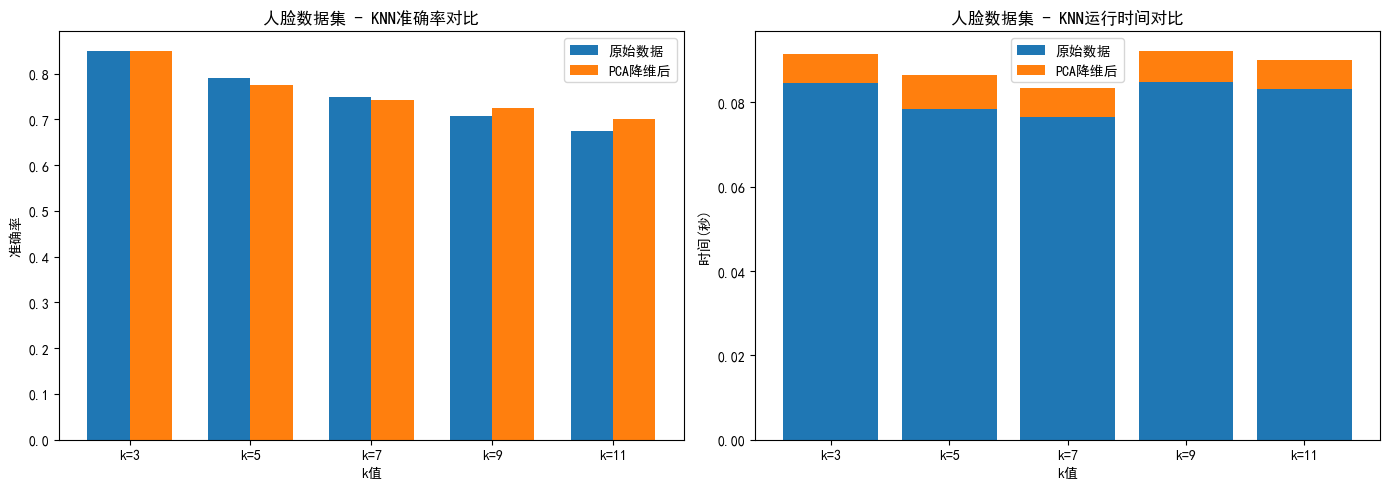

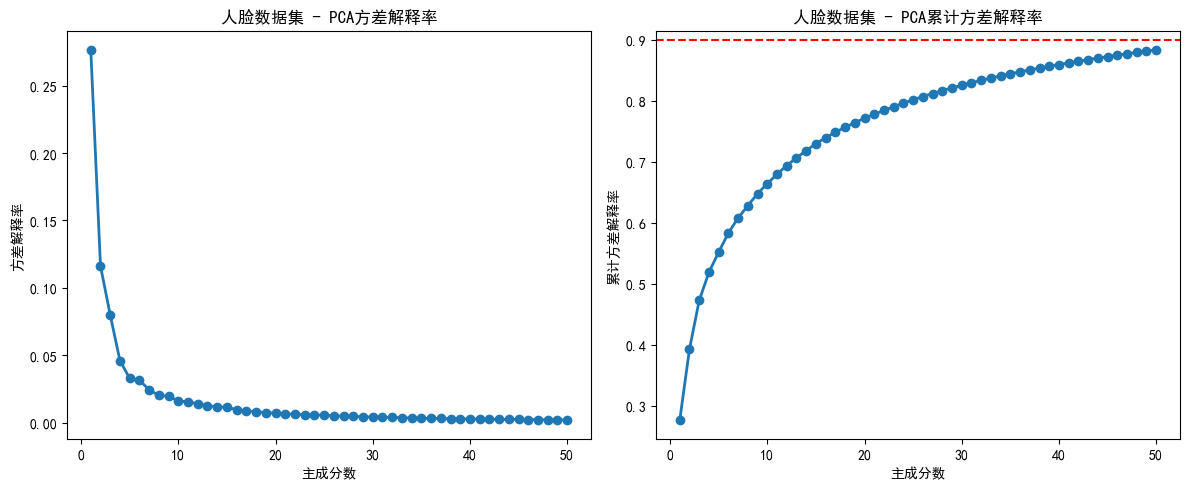

人脸数据集 - 达到90%方差解释率所需的主成分数: 1

人脸数据集 - PCA降维后最佳k值: 3


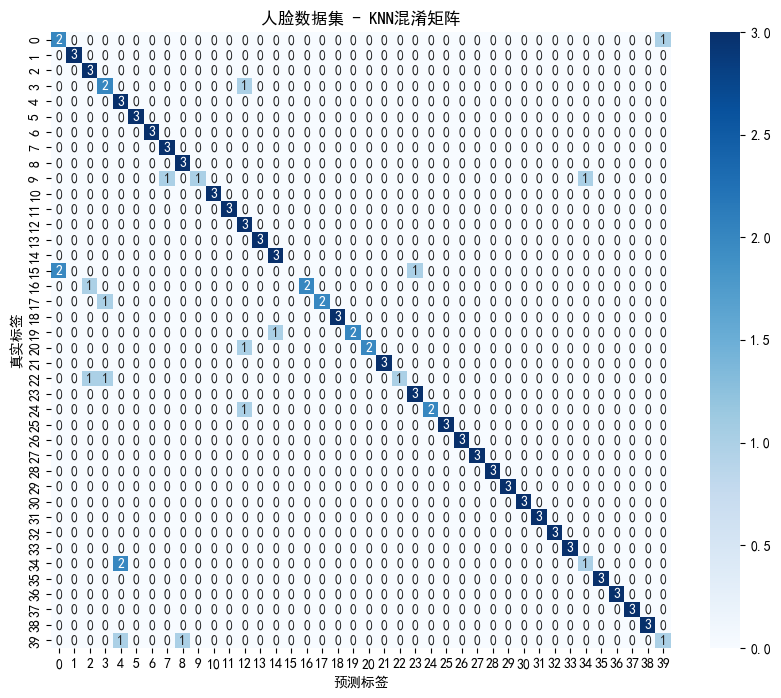


手写体数据集 - PCA降维信息:
  降维至 20 维
  累计方差解释率: 0.8000
  原始维度: 64, 降维后维度: 20

手写体数据集 - KNN分类实验:
  k=3:
    原始数据: 准确率=0.9722, 时间=0.0170秒
    PCA降维后: 准确率=0.9648, 时间=0.0160秒
    时间提升: 6.27%
  k=5:
    原始数据: 准确率=0.9704, 时间=0.0155秒
    PCA降维后: 准确率=0.9648, 时间=0.0150秒
    时间提升: 3.41%
  k=7:
    原始数据: 准确率=0.9685, 时间=0.0160秒
    PCA降维后: 准确率=0.9667, 时间=0.0140秒
    时间提升: 14.27%
  k=9:
    原始数据: 准确率=0.9667, 时间=0.0150秒
    PCA降维后: 准确率=0.9704, 时间=0.0150秒
    时间提升: -0.02%
  k=11:
    原始数据: 准确率=0.9648, 时间=0.0140秒
    PCA降维后: 准确率=0.9648, 时间=0.0141秒
    时间提升: -0.36%


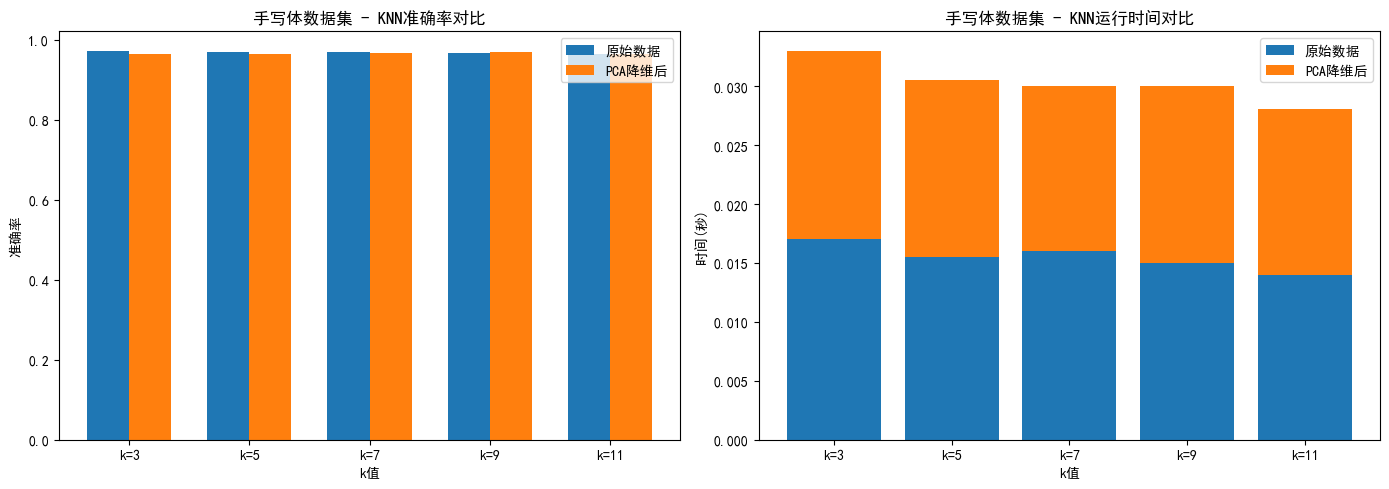

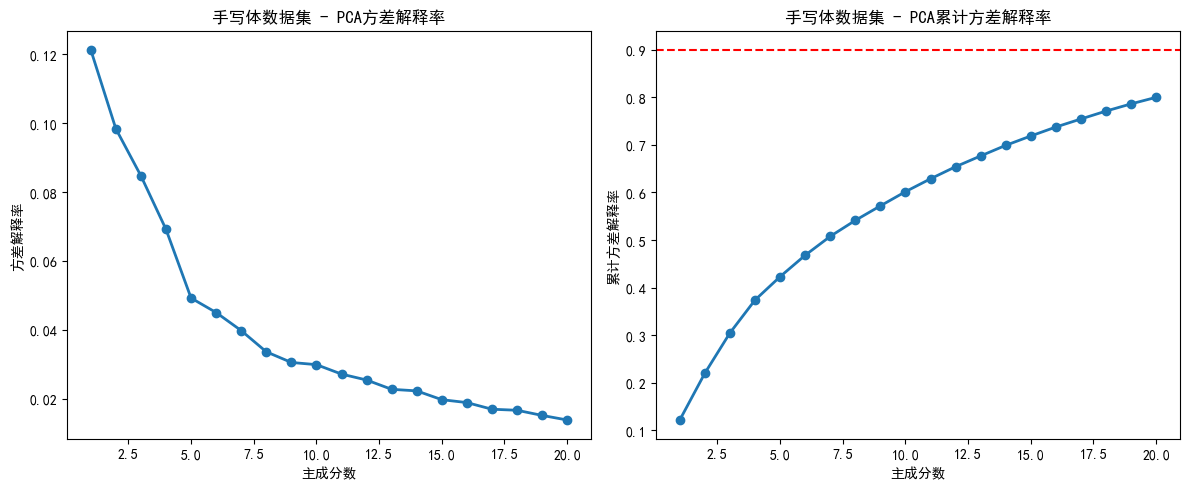

手写体数据集 - 达到90%方差解释率所需的主成分数: 1

手写体数据集 - PCA降维后最佳k值: 9


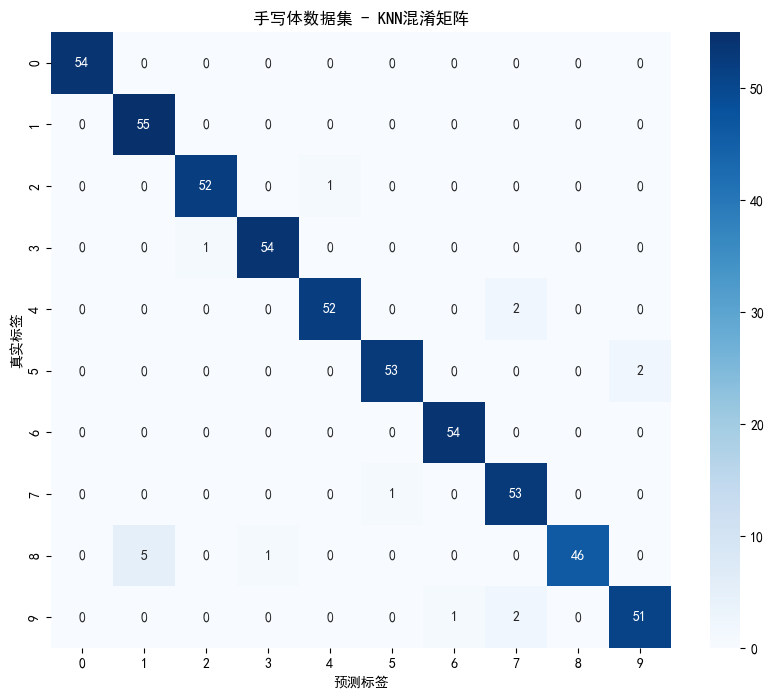

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces, load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据集
def load_datasets():
    """加载人脸和手写体数据集"""
    # 加载人脸数据集
    faces = fetch_olivetti_faces()
    X_faces, y_faces = faces.data, faces.target
    face_images = faces.images
    
    # 加载手写体数据集
    digits = load_digits()
    X_digits, y_digits = digits.data, digits.target
    digit_images = digits.images
    
    print("数据加载完成:")
    print(f"  人脸数据集: {X_faces.shape[0]} 样本, {X_faces.shape[1]} 特征")
    print(f"  手写体数据集: {X_digits.shape[0]} 样本, {X_digits.shape[1]} 特征")
    
    return X_faces, y_faces, face_images, X_digits, y_digits, digit_images

# 2. 数据预处理与降维
def preprocess_and_dim_reduction(X, y, dataset_name, n_components=50):
    """数据预处理、分割、PCA降维"""
    # 分割数据集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # PCA降维
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 计算方差解释率
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    print(f"\n{dataset_name} - PCA降维信息:")
    print(f"  降维至 {n_components} 维")
    print(f"  累计方差解释率: {cumulative_variance[-1]:.4f}")
    print(f"  原始维度: {X_train.shape[1]}, 降维后维度: {X_train_pca.shape[1]}")
    
    return (X_train, X_test, y_train, y_test), (X_train_scaled, X_test_scaled), \
           (X_train_pca, X_test_pca), pca

# 3. KNN分类实验
def knn_classification_experiment(X_train, X_test, y_train, y_test, 
                                 X_train_pca, X_test_pca, 
                                 dataset_name, k_values=[3, 5, 7, 9, 11]):
    """对比原始数据和PCA降维后数据的KNN分类性能"""
    results = {
        'original': {'accuracy': [], 'time': []},
        'pca': {'accuracy': [], 'time': []}
    }
    
    print(f"\n{dataset_name} - KNN分类实验:")
    
    for k in k_values:
        # 原始数据上的KNN
        knn_original = KNeighborsClassifier(n_neighbors=k)
        start_time = time.time()
        knn_original.fit(X_train, y_train)
        y_pred_original = knn_original.predict(X_test)
        end_time = time.time()
        
        accuracy_original = accuracy_score(y_test, y_pred_original)
        time_original = end_time - start_time
        
        # PCA降维后数据上的KNN
        knn_pca = KNeighborsClassifier(n_neighbors=k)
        start_time = time.time()
        knn_pca.fit(X_train_pca, y_train)
        y_pred_pca = knn_pca.predict(X_test_pca)
        end_time = time.time()
        
        accuracy_pca = accuracy_score(y_test, y_pred_pca)
        time_pca = end_time - start_time
        
        results['original']['accuracy'].append(accuracy_original)
        results['original']['time'].append(time_original)
        results['pca']['accuracy'].append(accuracy_pca)
        results['pca']['time'].append(time_pca)
        
        print(f"  k={k}:")
        print(f"    原始数据: 准确率={accuracy_original:.4f}, 时间={time_original:.4f}秒")
        print(f"    PCA降维后: 准确率={accuracy_pca:.4f}, 时间={time_pca:.4f}秒")
        print(f"    时间提升: {(time_original/time_pca-1):.2%}")
    
    return results

# 4. 可视化结果
def visualize_results(results, dataset_name, k_values):
    """可视化分类结果对比"""
    plt.figure(figsize=(14, 5))
    
    # 准确率对比
    plt.subplot(1, 2, 1)
    x = np.arange(len(k_values))
    width = 0.35
    plt.bar(x - width/2, results['original']['accuracy'], width, label='原始数据')
    plt.bar(x + width/2, results['pca']['accuracy'], width, label='PCA降维后')
    plt.xlabel('k值')
    plt.ylabel('准确率')
    plt.title(f"{dataset_name} - KNN准确率对比")
    plt.xticks(x, [f'k={k}' for k in k_values])
    plt.legend()
    
    # 时间对比
    plt.subplot(1, 2, 2)
    plt.bar([f'k={k}' for k in k_values], results['original']['time'], label='原始数据')
    plt.bar([f'k={k}' for k in k_values], results['pca']['time'], 
            bottom=results['original']['time'], label='PCA降维后')
    plt.xlabel('k值')
    plt.ylabel('时间(秒)')
    plt.title(f"{dataset_name} - KNN运行时间对比")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 5. 分析PCA降维效果
def analyze_pca_effect(pca, dataset_name):
    """分析PCA降维效果"""
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    plt.figure(figsize=(12, 5))
    
    # 方差解释率
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'o-', linewidth=2)
    plt.title(f'{dataset_name} - PCA方差解释率')
    plt.xlabel('主成分数')
    plt.ylabel('方差解释率')
    
    # 累计方差解释率
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', linewidth=2)
    plt.axhline(y=0.9, color='r', linestyle='--')
    plt.title(f'{dataset_name} - PCA累计方差解释率')
    plt.xlabel('主成分数')
    plt.ylabel('累计方差解释率')
    
    plt.tight_layout()
    plt.show()
    
    # 计算达到90%方差解释率所需的主成分数
    n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
    print(f"{dataset_name} - 达到90%方差解释率所需的主成分数: {n_components_90}")

# 6. 可视化混淆矩阵
def visualize_confusion_matrix(y_true, y_pred, dataset_name):
    """可视化混淆矩阵"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{dataset_name} - KNN混淆矩阵')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.show()

# 7. 主函数
def main():
    # 加载数据
    X_faces, y_faces, face_images, X_digits, y_digits, digit_images = load_datasets()
    
    # 人脸数据集实验
    face_params = (X_faces, y_faces, "人脸数据集", 50)  # 人脸数据降维至50维
    (X_faces_train, X_faces_test, y_faces_train, y_faces_test), \
    (X_faces_scaled_train, X_faces_scaled_test), \
    (X_faces_pca_train, X_faces_pca_test), face_pca = preprocess_and_dim_reduction(*face_params)
    
    face_results = knn_classification_experiment(
        X_faces_scaled_train, X_faces_scaled_test, y_faces_train, y_faces_test,
        X_faces_pca_train, X_faces_pca_test, "人脸数据集", k_values=[3, 5, 7, 9, 11]
    )
    
    visualize_results(face_results, "人脸数据集", [3, 5, 7, 9, 11])
    analyze_pca_effect(face_pca, "人脸数据集")
    
    # 找到人脸数据集的最佳k值
    best_k_face = [3, 5, 7, 9, 11][np.argmax(face_results['pca']['accuracy'])]
    print(f"\n人脸数据集 - PCA降维后最佳k值: {best_k_face}")
    
    # 使用最佳k值训练模型并可视化混淆矩阵
    best_knn_face = KNeighborsClassifier(n_neighbors=best_k_face)
    best_knn_face.fit(X_faces_pca_train, y_faces_train)
    y_pred_face = best_knn_face.predict(X_faces_pca_test)
    visualize_confusion_matrix(y_faces_test, y_pred_face, "人脸数据集")
    
    # 手写体数据集实验
    digit_params = (X_digits, y_digits, "手写体数据集", 20)  # 手写体数据降维至20维
    (X_digits_train, X_digits_test, y_digits_train, y_digits_test), \
    (X_digits_scaled_train, X_digits_scaled_test), \
    (X_digits_pca_train, X_digits_pca_test), digit_pca = preprocess_and_dim_reduction(*digit_params)
    
    digit_results = knn_classification_experiment(
        X_digits_scaled_train, X_digits_scaled_test, y_digits_train, y_digits_test,
        X_digits_pca_train, X_digits_pca_test, "手写体数据集", k_values=[3, 5, 7, 9, 11]
    )
    
    visualize_results(digit_results, "手写体数据集", [3, 5, 7, 9, 11])
    analyze_pca_effect(digit_pca, "手写体数据集")
    
    # 找到手写体数据集的最佳k值
    best_k_digit = [3, 5, 7, 9, 11][np.argmax(digit_results['pca']['accuracy'])]
    print(f"\n手写体数据集 - PCA降维后最佳k值: {best_k_digit}")
    
    # 使用最佳k值训练模型并可视化混淆矩阵
    best_knn_digit = KNeighborsClassifier(n_neighbors=best_k_digit)
    best_knn_digit.fit(X_digits_pca_train, y_digits_train)
    y_pred_digit = best_knn_digit.predict(X_digits_pca_test)
    visualize_confusion_matrix(y_digits_test, y_pred_digit, "手写体数据集")

if __name__ == "__main__":
    main()
